<a href="https://colab.research.google.com/github/Gutierrezjk/MIAD_ML_NLP_2025/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries - everything we need

# Data Analysis and Plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn Modelling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pickle for saving and loading our trained model
import pickle

# Step 1: Load and Explore the Dataset


In [ ]:
# Configure visualizations
sns.set(style='whitegrid')

In [ ]:
# Load dataset from the provided URL
url = 'https://raw.githubusercontent.com/muhammadanas0716/Machine-Learning-101/main/Datasets/spam.csv'
df = pd.read_csv(url, encoding='latin-1')

In [ ]:
# Select only relevant columns and rename them for better readability
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

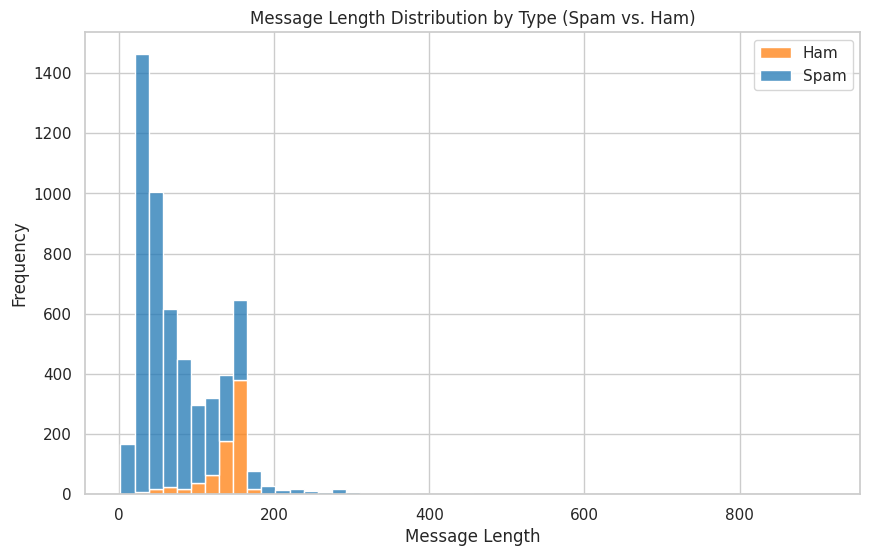

In [ ]:
# Add message length column
df['message_length'] = df['message'].apply(len)

# Plot message length distribution by label
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='message_length', hue='label', multiple='stack', bins=50, palette=['#1f77b4', '#ff7f0e'])
plt.title('Message Length Distribution by Type (Spam vs. Ham)')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend(['Ham', 'Spam'])
plt.show()


In [ ]:
# Display the first few rows to understand the structure
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


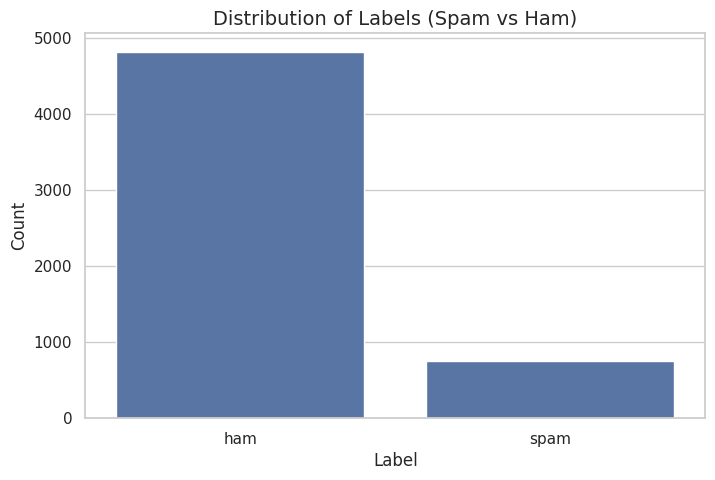

In [ ]:
# Plotting the distribution of 'ham' and 'spam' labels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label')
plt.title('Distribution of Labels (Spam vs Ham)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Step 2: Data Preprocessing

In [ ]:
# ### Convert labels to binary values (0 for 'ham', 1 for 'spam')
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Ensure no missing values exist in the dataset
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 label             0
message           0
message_length    0
dtype: int64


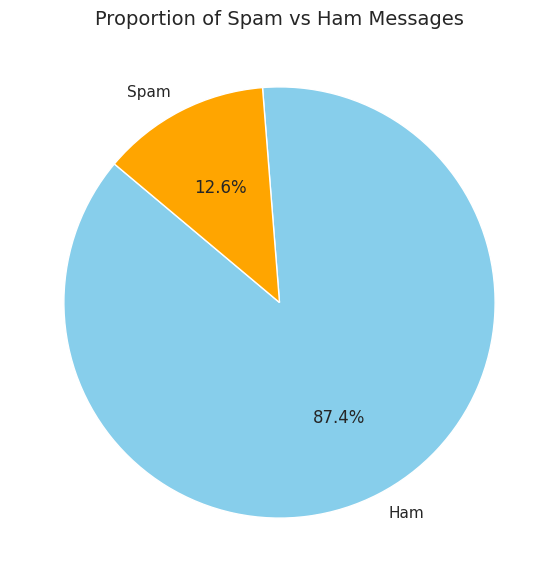

In [ ]:
# Visualize updated distribution as a pie chart
plt.figure(figsize=(7, 7))
df['label'].value_counts().plot(kind='pie', labels=['Ham', 'Spam'], autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange'])
plt.title('Proportion of Spam vs Ham Messages', fontsize=14)
plt.ylabel('')
plt.show()

# Step 3: Splitting the Data

In [ ]:
# Prepare features (X) and target (y)
X = df['message']  # Text messages
y = df['label']    # Corresponding labels (0 or 1)

In [ ]:
# Split into train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 4: Text Vectorization using TF-IDF

In [ ]:
# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

In [ ]:
# Transform the text data into TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Step 5: Model Training using Naive Bayes


In [ ]:
# Initialize and train the Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

# Step 6: Model Evaluation

In [ ]:
# Make predictions on the test data
y_pred = nb_model.predict(X_test_tfidf)

In [ ]:
# Calculate and display the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.96


In [ ]:
# Generate and print a detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1107
           1       1.00      0.73      0.84       186

    accuracy                           0.96      1293
   macro avg       0.98      0.86      0.91      1293
weighted avg       0.96      0.96      0.96      1293



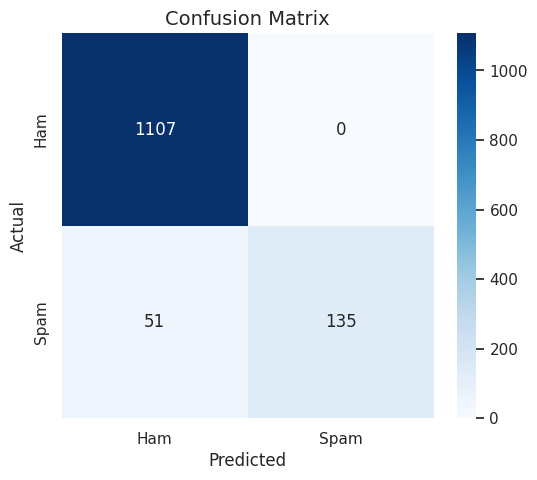

In [ ]:
# Display a confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='d', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

The classification report shows that the model has high accuracy (96%) for distinguishing between 'Ham' (normal messages) and 'Spam' (unwanted messages).

Precision indicates the correctness of positive predictions, with 'Spam' achieving a perfect 1.00, meaning all predicted Spam messages were truly Spam. 'Ham' precision is 0.96, indicating slight misclassification.
Recall measures coverage of actual positive cases. The recall for 'Spam' is 0.73, showing the model missed 27% of Spam messages, while for 'Ham' it is perfect at 1.00.
F1-Score balances precision and recall, with 'Ham' achieving 0.98 and 'Spam' 0.84.
The confusion matrix highlights:

1. 1107 true positives (correct Ham predictions).
2. 135 true negatives (correct Spam predictions).
3. 51 false negatives (Spam predicted as Ham), with no false positives.

The model performs well for Ham but struggles with some Spam messages, as shown by the lower recall and 51 undetected Spam instances.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters found: {'alpha': 0.1}
Model Accuracy after Grid Search: 0.98

Classification Report after Grid Search:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1107
           1       0.97      0.90      0.93       186

    accuracy                           0.98      1293
   macro avg       0.98      0.95      0.96      1293
weighted avg       0.98      0.98      0.98      1293



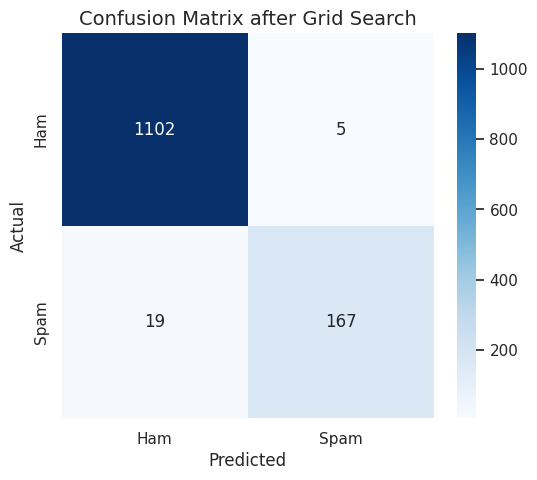

In [ ]:
# Import necessary libraries for Grid Search
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]  # Smoothing parameter for MultinomialNB
}

# Initialize Grid Search with cross-validation (cv=5 for 5-fold cross-validation)
grid_search = GridSearchCV(estimator=MultinomialNB(), param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Perform the grid search on the training data
grid_search.fit(X_train_tfidf, y_train)

# Display the best hyperparameters found
print(f"Best parameters found: {grid_search.best_params_}")

# Train a new model with the best parameters
best_nb_model = grid_search.best_estimator_

# Evaluate the model using the test set
y_pred_best = best_nb_model.predict(X_test_tfidf)

# Calculate and print the new accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Model Accuracy after Grid Search: {accuracy_best:.2f}')

# Display a detailed classification report
print("\nClassification Report after Grid Search:\n", classification_report(y_test, y_pred_best))

# Display the new confusion matrix
conf_mat_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat_best, annot=True, cmap='Blues', fmt='d', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix after Grid Search', fontsize=14)
plt.show()


# Step 7: Save the Model and Vectorizer

In [ ]:
# Save the trained Naive Bayes model
with open('naive_bayes_model.pkl', 'wb') as model_file:
    pickle.dump(nb_model, model_file)

In [ ]:
# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

# Step 8: Load the Model and Make Custom Predictions

In [ ]:
# Save the best model obtained from Grid Search
with open('best_naive_bayes_model.pkl', 'wb') as model_file:
    pickle.dump(best_nb_model, model_file)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)


In [ ]:
# Load the saved model
with open('best_naive_bayes_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# Load the saved vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as vectorizer_file:
    loaded_vectorizer = pickle.load(vectorizer_file)

# Custom input messages for prediction
custom_messages = [
    "Free money here! Claim your prize now.",
    "You have won the lottery! Contact us to collect your winnings.",
    "Hey, just checking in to see how you are doing!",
    "Urgent: Please confirm your bank details immediately."
]

# Transform the custom messages using the loaded vectorizer
custom_messages_tfidf = loaded_vectorizer.transform(custom_messages)

# Predict using the loaded model
predictions = loaded_model.predict(custom_messages_tfidf)

# Display the predictions
print("\nCustom Message Predictions:")
for message, label in zip(custom_messages, predictions):
    label_text = 'Spam' if label == 1 else 'Ham'
    print(f'Message: \"{message}\" - Prediction: {label_text}')



Custom Message Predictions:
Message: "Free money here! Claim your prize now." - Prediction: Spam
Message: "You have won the lottery! Contact us to collect your winnings." - Prediction: Spam
Message: "Hey, just checking in to see how you are doing!" - Prediction: Ham
Message: "Urgent: Please confirm your bank details immediately." - Prediction: Spam
